# Exploring visualizations

In [56]:
import os
import random
import pandas as pd
import numpy as np
import tensorflow as tf
from PIL import Image

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


In [57]:
CLASS_NAMES = [
    "Black Sea Sprat",      # 0
    "Gilt-Head Bream",      # 1
    "Hourse Mackerel",      # 2
    "Red Mullet",           # 3
    "Red Sea Bream",        # 4
    "Sea Bass",             # 5
    "Shrimp",               # 6
    "Striped Red Mullet",   # 7
    "Trout",                # 8
]
print(CLASS_NAMES)

# set to the folder that directly contains the 9 label folders.
src_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset'
# set to a NEW output folder where the notebook will copy images,
# removing any subfolders whose name ends with "GT".
clean_dir = '/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset_clean'
# After cleaning, clean_dir should look like:
# <clean_dir>/<Label_i>/<image_files...>

SEED = 42
random.seed(SEED)

['Black Sea Sprat', 'Gilt-Head Bream', 'Hourse Mackerel', 'Red Mullet', 'Red Sea Bream', 'Sea Bass', 'Shrimp', 'Striped Red Mullet', 'Trout']


# load some images

In [58]:
selected_rows = []

for cls in CLASS_NAMES:
    class_dir = os.path.join(src_dir, cls)
    if not os.path.isdir(class_dir):
        raise FileNotFoundError(f"Missing class folder: {class_dir}")

    # The dataset has an extra nested folder level; we collect from the subfolder(s) that match the class
    # and skip anything ending with GT.
    candidate_img_paths = []
    for subfolder in os.listdir(class_dir):
        sub_path = os.path.join(class_dir, subfolder)
        if not os.path.isdir(sub_path):
            continue
        if subfolder.endswith("GT"):
            continue
        if subfolder != cls:
            continue

        for fname in os.listdir(sub_path):
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                candidate_img_paths.append(os.path.join(sub_path, fname))

    if len(candidate_img_paths) < 3:
        raise ValueError(f"Not enough images for class '{cls}'. Found {len(candidate_img_paths)}")

    chosen = random.sample(candidate_img_paths, 3)
    for p in chosen:
        selected_rows.append({"img_path": p, "true_label_name": cls})

mini_eval_df = pd.DataFrame(selected_rows)
print("Mini eval size:", len(mini_eval_df))
mini_eval_df.head()

Mini eval size: 27


,img_path,true_label_name
0,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat
1,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat
2,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat
3,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream
4,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream


In [59]:
model = tf.keras.models.load_model("Fish_MN.keras")

# Build mapping index -> label name (based on output order)
# IMPORTANT: this assumes the model output index ordering matches CLASS_NAMES order.
idx_to_name = {i: name for i, name in enumerate(CLASS_NAMES)}

def load_and_preprocess_image(path, target_size=(224, 224)):
    img = Image.open(path).convert("RGB").resize(target_size)
    arr = np.array(img).astype("float32")
    arr = preprocess_input(arr)  # MobileNetV2 specific
    return arr

# Predict
pred_records = []

for i, row in mini_eval_df.iterrows():
    x = load_and_preprocess_image(row["img_path"])
    x = np.expand_dims(x, axis=0)  # batch dimension

    probs = model.predict(x, verbose=0)[0]  # shape: (num_classes,)
    pred_idx = int(np.argmax(probs))
    pred_name = idx_to_name[pred_idx]
    true_name = row["true_label_name"]

    pred_records.append({
        "img_path": row["img_path"],
        "true_label_name": true_name,
        "pred_label_name": pred_name,
        "pred_prob": float(probs[pred_idx]),
        "pred_idx": pred_idx
    })

pred_df = pd.DataFrame(pred_records)

# Quick overview
pred_df.sort_values("true_label_name").reset_index(drop=True).head(30)

,img_path,true_label_name,pred_label_name,pred_prob,pred_idx
0,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat,Black Sea Sprat,0.999807,0
1,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat,Black Sea Sprat,0.993474,0
2,/home/groggy/data/a-large-scale-fish-dataset/2...,Black Sea Sprat,Black Sea Sprat,0.998927,0
3,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream,Gilt-Head Bream,0.951561,1
4,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream,Red Sea Bream,0.674478,4
5,/home/groggy/data/a-large-scale-fish-dataset/2...,Gilt-Head Bream,Gilt-Head Bream,0.997633,1
6,/home/groggy/data/a-large-scale-fish-dataset/2...,Hourse Mackerel,Hourse Mackerel,0.998368,2
7,/home/groggy/data/a-large-scale-fish-dataset/2...,Hourse Mackerel,Hourse Mackerel,0.999977,2
8,/home/groggy/data/a-large-scale-fish-dataset/2...,Hourse Mackerel,Hourse Mackerel,0.999687,2
9,/home/groggy/data/a-large-scale-fish-dataset/2...,Red Mullet,Red Mullet,0.999918,3


In [60]:
for _, r in pred_df.iterrows():
    print(f"TRUE: {r['true_label_name']:20s}  |  PRED: {r['pred_label_name']:20s}  |  prob={r['pred_prob']:.3f}")

TRUE: Black Sea Sprat       |  PRED: Black Sea Sprat       |  prob=1.000
TRUE: Black Sea Sprat       |  PRED: Black Sea Sprat       |  prob=0.993
TRUE: Black Sea Sprat       |  PRED: Black Sea Sprat       |  prob=0.999
TRUE: Gilt-Head Bream       |  PRED: Gilt-Head Bream       |  prob=0.952
TRUE: Gilt-Head Bream       |  PRED: Red Sea Bream         |  prob=0.674
TRUE: Gilt-Head Bream       |  PRED: Gilt-Head Bream       |  prob=0.998
TRUE: Hourse Mackerel       |  PRED: Hourse Mackerel       |  prob=0.998
TRUE: Hourse Mackerel       |  PRED: Hourse Mackerel       |  prob=1.000
TRUE: Hourse Mackerel       |  PRED: Hourse Mackerel       |  prob=1.000
TRUE: Red Mullet            |  PRED: Red Mullet            |  prob=1.000
TRUE: Red Mullet            |  PRED: Red Mullet            |  prob=1.000
TRUE: Red Mullet            |  PRED: Red Mullet            |  prob=1.000
TRUE: Red Sea Bream         |  PRED: Red Sea Bream         |  prob=1.000
TRUE: Red Sea Bream         |  PRED: Red Sea Bream 

# Grad-CAM visualization

In [61]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from PIL import Image
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [62]:
model = tf.keras.models.load_model("Fish_MN.keras")
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         4,617 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,239,453 (16.17 MB)

 Trainable params: 660,489 (2.52 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 1,320,980 (5.04 MB)

In [63]:
conv_candidates = []
for layer in model.layers:
    # direct layers only (we'll also look deeper if needed)
    try:
        if len(layer.output_shape) == 4:
            conv_candidates.append(layer)
    except Exception:
        pass

print("Top-level 4D layers:", [l.name for l in conv_candidates])

# More robust: find the last conv-like layer anywhere in the model graph
target_layer = None
for layer in reversed(model.layers):
    # Try to identify actual conv layers by dimensionality + type name
    if "conv" in layer.name.lower():
        try:
            if len(layer.output_shape) == 4:
                target_layer = layer.name
                break
        except Exception:
            continue

# Fallback: last 4D layer if conv name search fails
if target_layer is None:
    for layer in reversed(model.layers):
        try:
            if len(layer.output_shape) == 4:
                target_layer = layer.name
                break
        except Exception:
            continue

print("Selected Grad-CAM target layer:", target_layer)

Top-level 4D layers: ['mobilenetv2_1.00_224']
Selected Grad-CAM target layer: mobilenetv2_1.00_224


In [64]:
print("Target conv layer for Grad-CAM:", target_layer)

Target conv layer for Grad-CAM: mobilenetv2_1.00_224


In [71]:
def load_and_preprocess_for_model(path, target_size=(224,224)):
    img = Image.open(path).convert("RGB").resize(target_size)
    arr = np.array(img).astype("float32")
    arr = preprocess_input(arr)  # MobileNetV2 preprocessing
    return img, arr

def make_gradcam_heatmap_from_layer_tensor(img_tensor, model, target_layer_name, class_index=None):
    # Get intermediate layer outputs by calling the model in pieces

    # First, pass through MobileNetV2
    mobilenet_layer = model.get_layer(target_layer_name)

    # Get all subsequent layers
    subsequent_layers = model.layers[model.layers.index(mobilenet_layer) + 1:]

    with tf.GradientTape() as tape:
        # Forward pass through MobileNetV2
        conv_outputs = mobilenet_layer(img_tensor, training=False)
        tape.watch(conv_outputs)

        # Forward pass through remaining layers
        x = conv_outputs
        for layer in subsequent_layers:
            x = layer(x, training=False)
        predictions = x

        if class_index is None:
            class_index = int(tf.argmax(predictions[0]))

        class_score = predictions[:, class_index]

    grads = tape.gradient(class_score, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(1, 2))

    conv_outputs = conv_outputs[0]
    pooled_grads = pooled_grads[0]

    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy(), int(class_index)

def overlay_heatmap_on_image(pil_img, heatmap, alpha=0.4):
    heatmap_resized = np.array(
        Image.fromarray((heatmap * 255).astype(np.uint8)).resize(pil_img.size)
    )

    # Colorize heatmap (Jet colormap style)
    plt.figure(figsize=(4,4))
    plt.axis("off")

    import matplotlib.cm as cm
    colored = cm.get_cmap("jet")(heatmap_resized / 255.0)  # (H, W, 4)
    colored = (colored[..., :3] * 255).astype(np.uint8)

    overlay = (np.array(pil_img).astype(np.float32) * (1 - alpha) + colored.astype(np.float32) * alpha).astype(np.uint8)
    return Image.fromarray(overlay)

/tmp/ipykernel_88325/155701665.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colored = cm.get_cmap("jet")(heatmap_resized / 255.0)  # (H, W, 4)


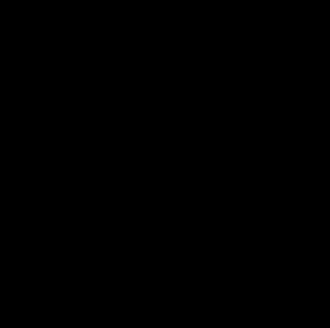

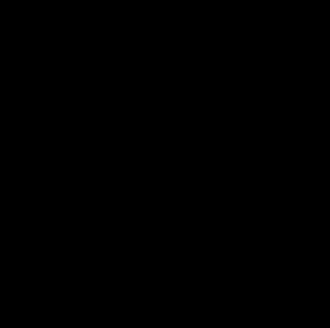

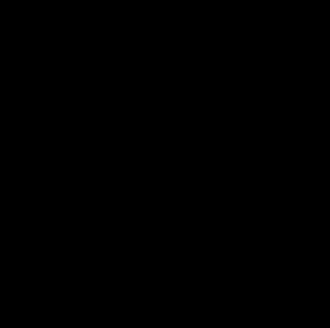

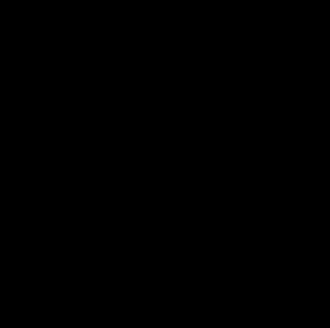

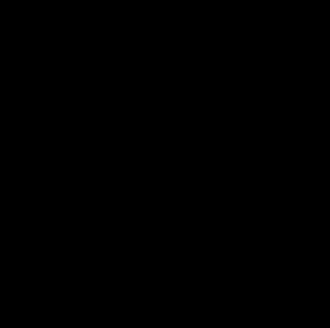

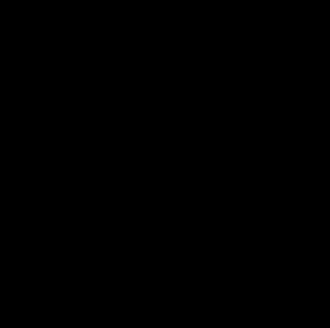

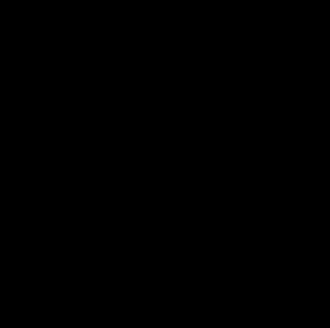

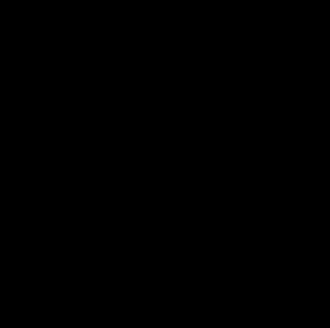

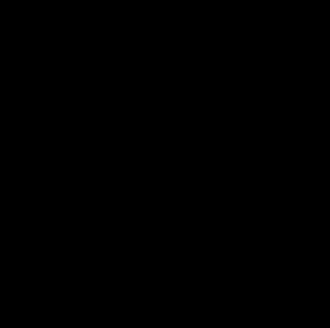

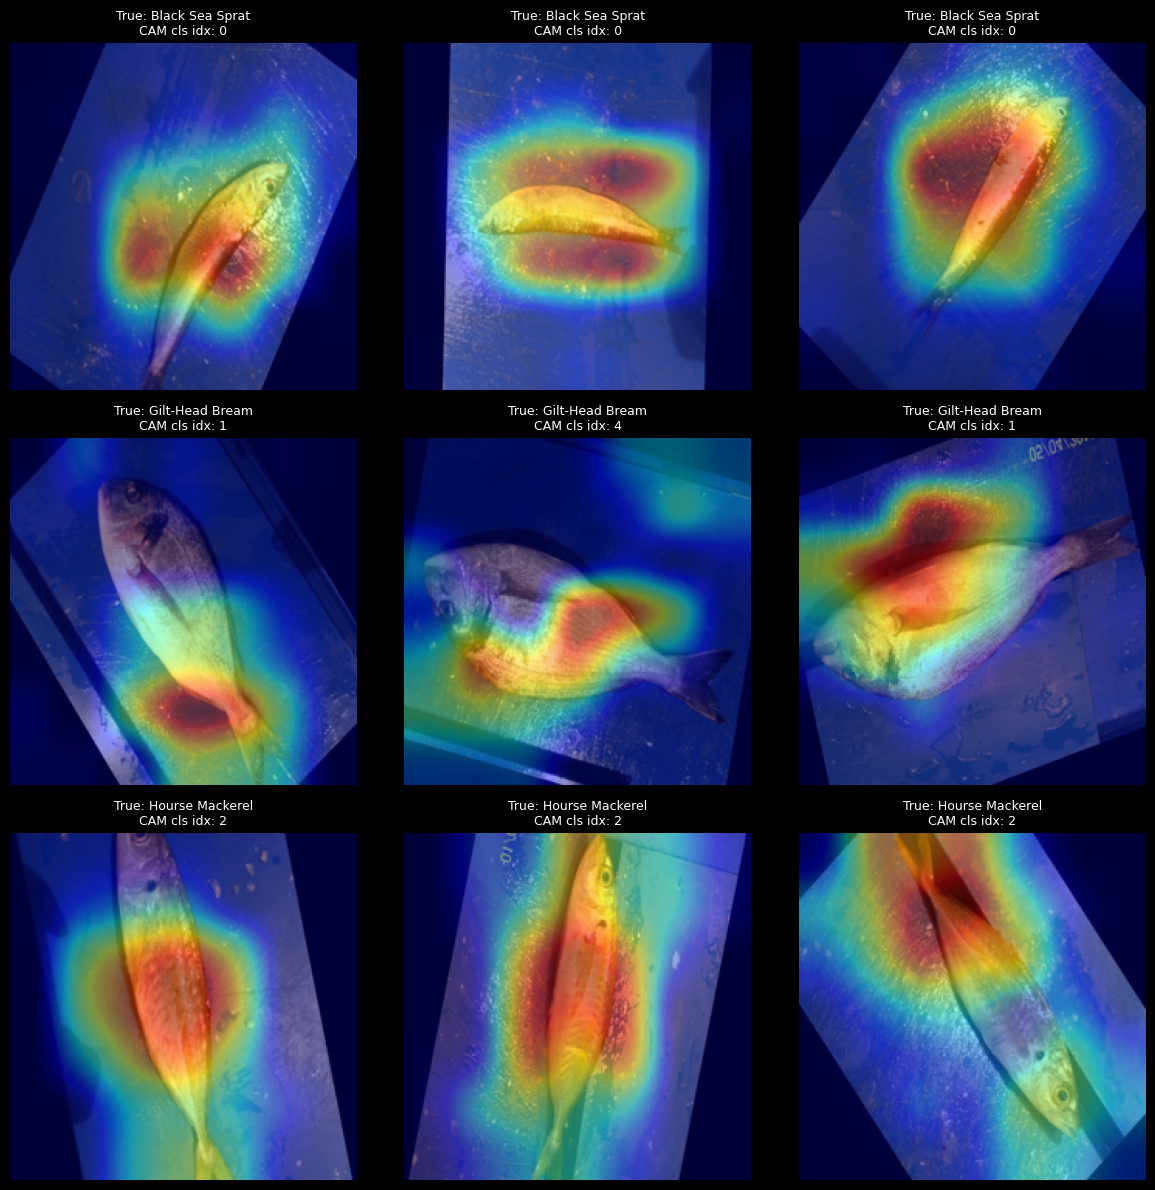

In [75]:
show_n = 9  # show a 3x3 preview
indices_to_show = list(range(min(show_n, len(mini_eval_df))))

results = []
target_layer_name = "mobilenetv2_1.00_224"

for i in indices_to_show:
    path = mini_eval_df.loc[i, "img_path"]
    true_name = mini_eval_df.loc[i, "true_label_name"]

    pil_img, x = load_and_preprocess_for_model(path)

    # If you have pred_df with pred_idx, use that for class_index; else use argmax
    class_index = None
    if 'pred_df' in globals() and len(pred_df) == len(mini_eval_df):
        class_index = int(pred_df.loc[i, "pred_idx"])

    heatmap, used_class_index = make_gradcam_heatmap_from_layer_tensor(
        img_tensor=np.expand_dims(x, axis=0),
        model=model,
        target_layer_name=target_layer_name,
        class_index=class_index
    )

    overlay_img = overlay_heatmap_on_image(pil_img, heatmap, alpha=0.45)

    results.append((path, true_name, used_class_index, overlay_img))

# Plot preview
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax_i, (path, true_name, used_class_index, overlay_img) in zip(range(len(results)), results):
    ax = axes[ax_i]
    ax.imshow(overlay_img)
    ax.axis("off")
    ax.set_title(f"True: {true_name}\nCAM cls idx: {used_class_index}", fontsize=9)

plt.tight_layout()
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [78]:
print(i, "heatmap stats:", np.min(heatmap), np.max(heatmap), "mean:", np.mean(heatmap))

5 heatmap stats: 0.0 0.99999386 mean: 0.21627808


In [73]:
   [l.name for l in model.layers]

['input_layer_1',
 'mobilenetv2_1.00_224',
 'global_average_pooling2d',
 'dense',
 'dropout',
 'dense_1']

In [74]:
plt.savefig('gradcam_results.png', dpi=150, bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>

/tmp/ipykernel_88325/155701665.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colored = cm.get_cmap("jet")(heatmap_resized / 255.0)  # (H, W, 4)


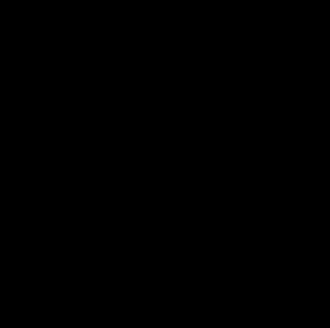

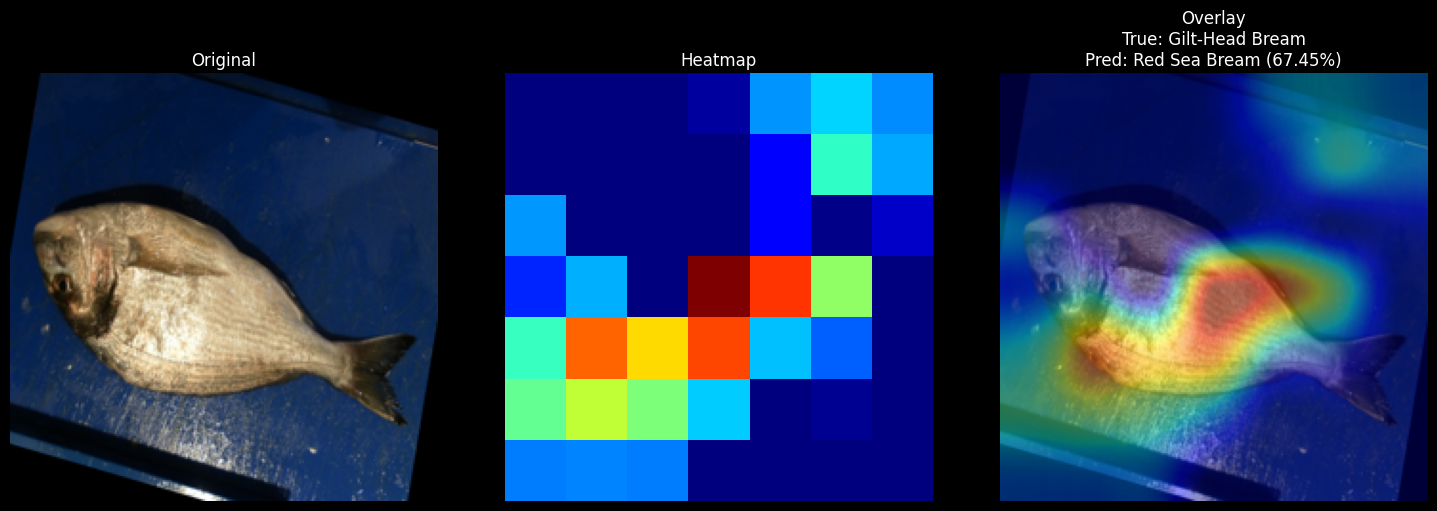

In [76]:
# Look at the misclassification case (index 4: Gilt-Head Bream predicted as Red Sea Bream)
i = 4
path = mini_eval_df.loc[i, "img_path"]
pil_img, x = load_and_preprocess_for_model(path)

heatmap, used_class_index = make_gradcam_heatmap_from_layer_tensor(
    img_tensor=np.expand_dims(x, axis=0),
    model=model,
    target_layer_name=target_layer_name,
    class_index=int(pred_df.loc[i, "pred_idx"])
)

overlay_img = overlay_heatmap_on_image(pil_img, heatmap, alpha=0.45)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pil_img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title('Heatmap')
axes[1].axis('off')

axes[2].imshow(overlay_img)
axes[2].set_title(
    f'Overlay\nTrue: {mini_eval_df.loc[i, "true_label_name"]}\nPred: {pred_df.loc[i, "pred_label_name"]} ({pred_df.loc[i, "pred_prob"]:.2%})')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'gradcam_analysis_sample_{i}.png', dpi=150)
plt.show()


/tmp/ipykernel_88325/155701665.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colored = cm.get_cmap("jet")(heatmap_resized / 255.0)  # (H, W, 4)


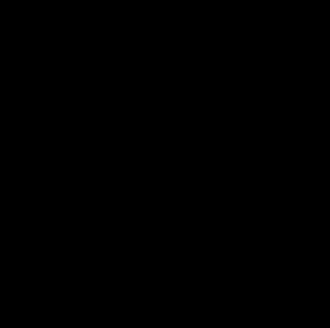

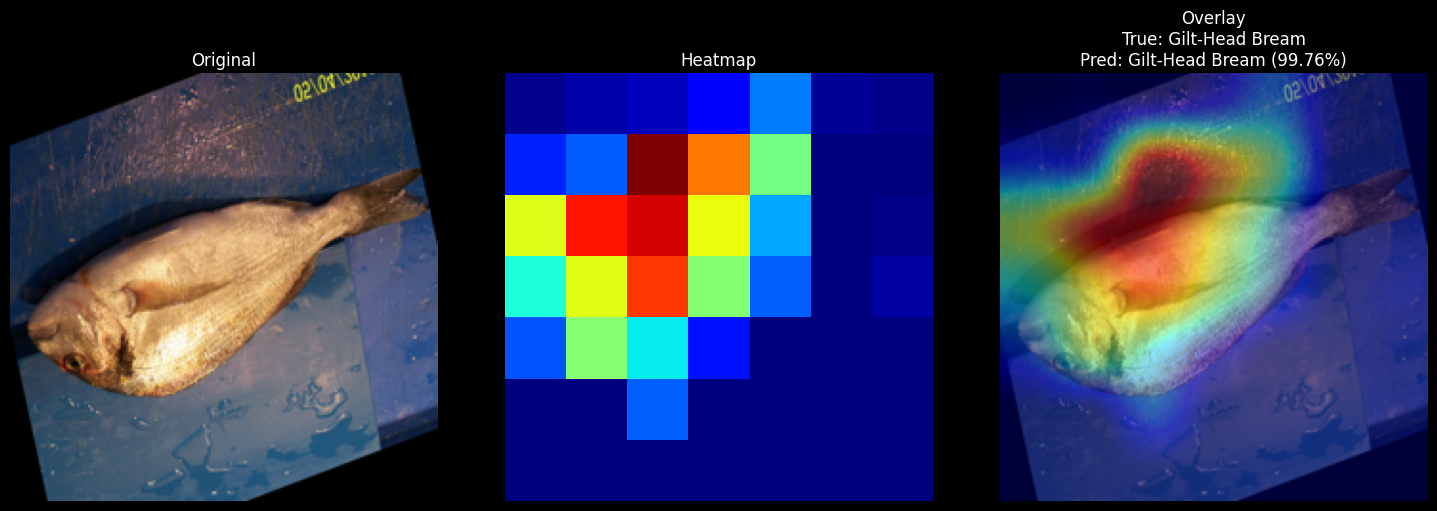

In [77]:
i = 5
path = mini_eval_df.loc[i, "img_path"]
pil_img, x = load_and_preprocess_for_model(path)

heatmap, used_class_index = make_gradcam_heatmap_from_layer_tensor(
    img_tensor=np.expand_dims(x, axis=0),
    model=model,
    target_layer_name=target_layer_name,
    class_index=int(pred_df.loc[i, "pred_idx"])
)

overlay_img = overlay_heatmap_on_image(pil_img, heatmap, alpha=0.45)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(pil_img)
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(heatmap, cmap='jet')
axes[1].set_title('Heatmap')
axes[1].axis('off')

axes[2].imshow(overlay_img)
axes[2].set_title(
    f'Overlay\nTrue: {mini_eval_df.loc[i, "true_label_name"]}\nPred: {pred_df.loc[i, "pred_label_name"]} ({pred_df.loc[i, "pred_prob"]:.2%})')
axes[2].axis('off')

plt.tight_layout()
plt.savefig(f'gradcam_analysis_sample_{i}.png', dpi=150)
plt.show()


# single image in and image out


Saved to images/WrongClass.png


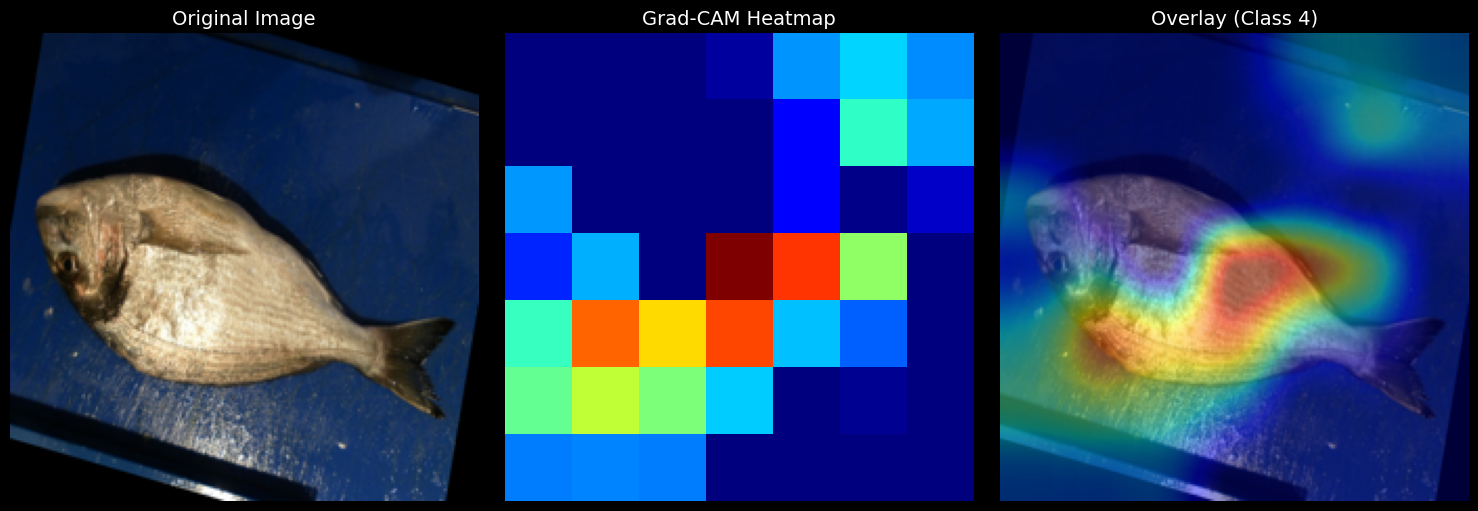

Saved to images/RedSea_vs_GiltHead.png


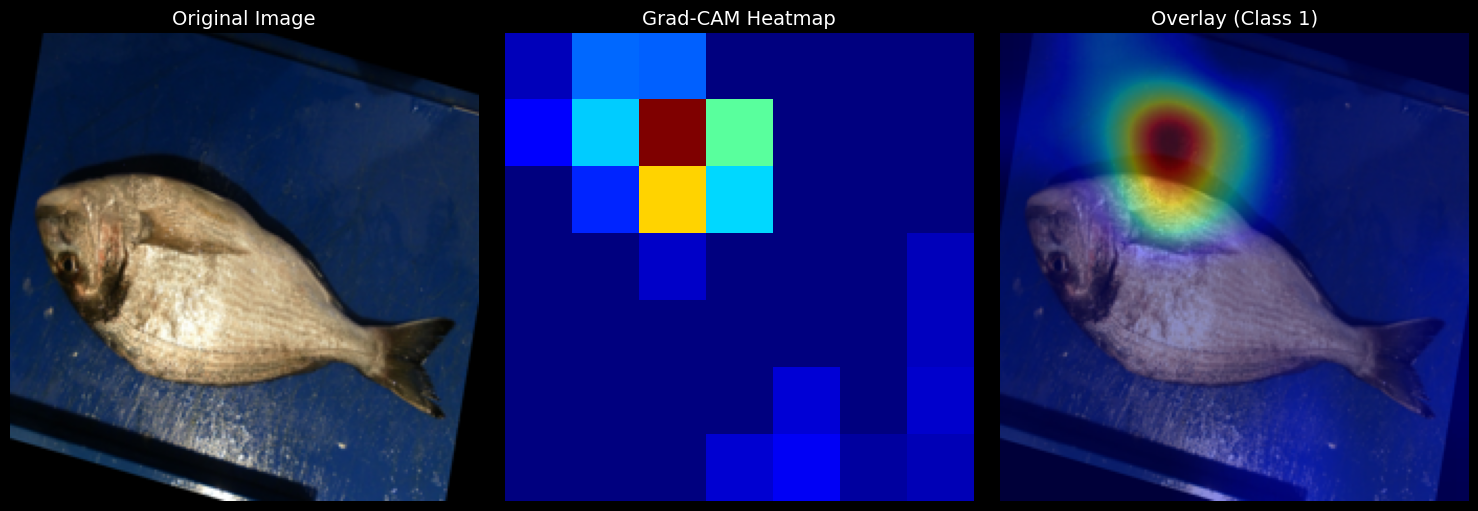

Saved to images/RedSea_vs_GiltHead.png


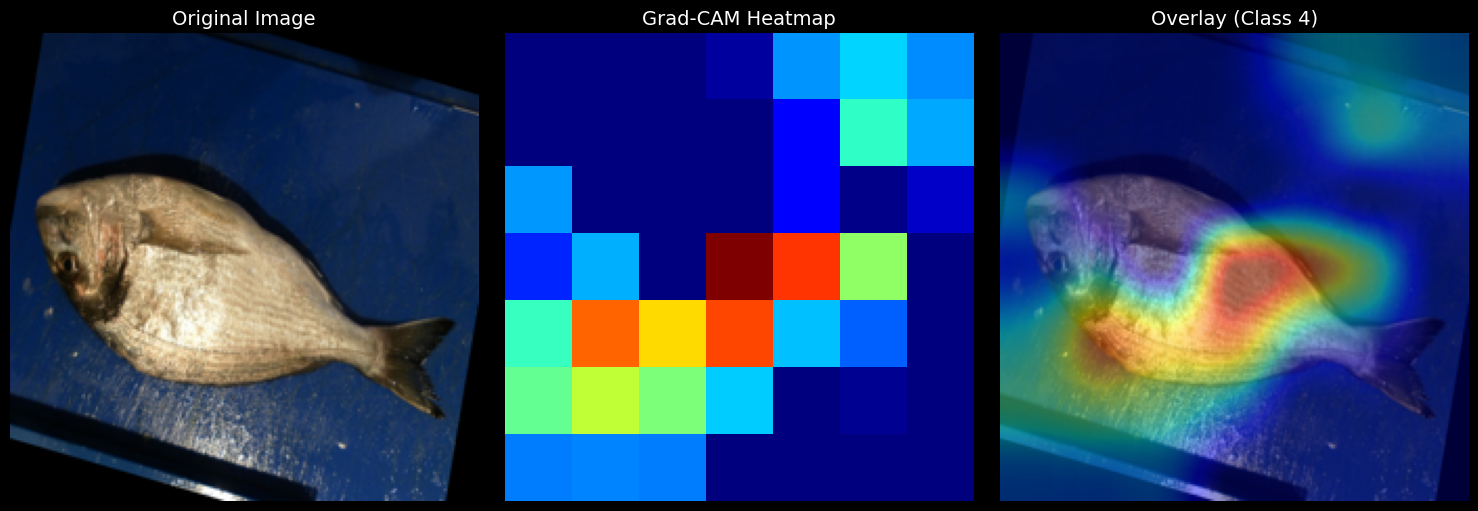

(<PIL.Image.Image image mode=RGB size=224x224>,
 array([[0.        , 0.        , 0.        , 0.02772246, 0.27233478,
         0.33551714, 0.2630651 ],
        [0.        , 0.        , 0.        , 0.        , 0.12096375,
         0.4089968 , 0.2917442 ],
        [0.27579713, 0.        , 0.        , 0.        , 0.12444501,
         0.0102784 , 0.06525385],
        [0.16206305, 0.29689234, 0.        , 0.99999976, 0.85454893,
         0.5259549 , 0.        ],
        [0.41764045, 0.80257976, 0.6781843 , 0.8326116 , 0.3159681 ,
         0.2193498 , 0.        ],
        [0.46931276, 0.58414036, 0.50064623, 0.32582897, 0.        ,
         0.01931578, 0.        ],
        [0.2470858 , 0.2555277 , 0.24710289, 0.        , 0.        ,
         0.        , 0.        ]], dtype=float32),
 <PIL.Image.Image image mode=RGB size=224x224>,
 4)

In [98]:
# Import the function
from gradcam_single_image import visualize_gradcam

# Example: visualize any image
img_path = mini_eval_df.loc[4, "img_path"]  # The misclassified Gilt-Head Bream


img, heatmap, overlay, class_idx = visualize_gradcam(
    img_path=img_path,
    model=model,
    save_path='images/WrongClass.png'
)

# Or with a specific class index
visualize_gradcam(
    img_path=img_path,
    model=model,
    class_index=1,  # Force it to show what makes it look like Gilt-Head Bream
    save_path='images/RedSea_vs_GiltHead.png'
)

visualize_gradcam(
    img_path=img_path,
    model=model,
    class_index=4,  # Force it to show what makes it look like Red-Sea_Bream
    save_path='images/RedSea_vs_GiltHead.png'
)


Saved to images/my_gradcam.png


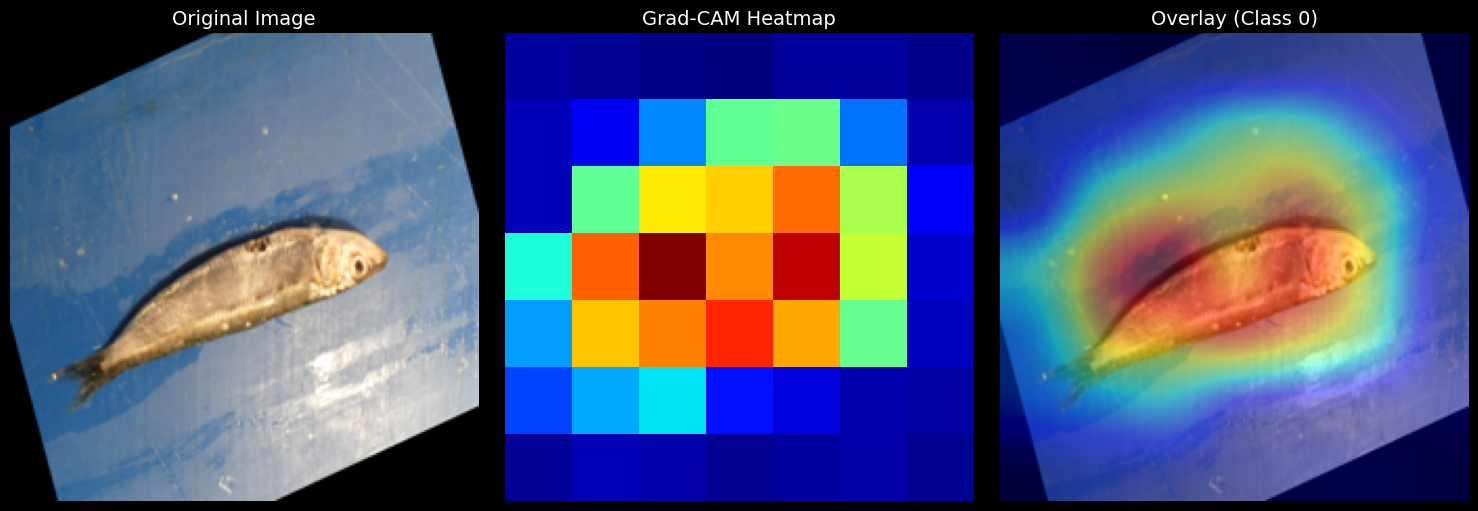

Saved to images/forced_class_0.png


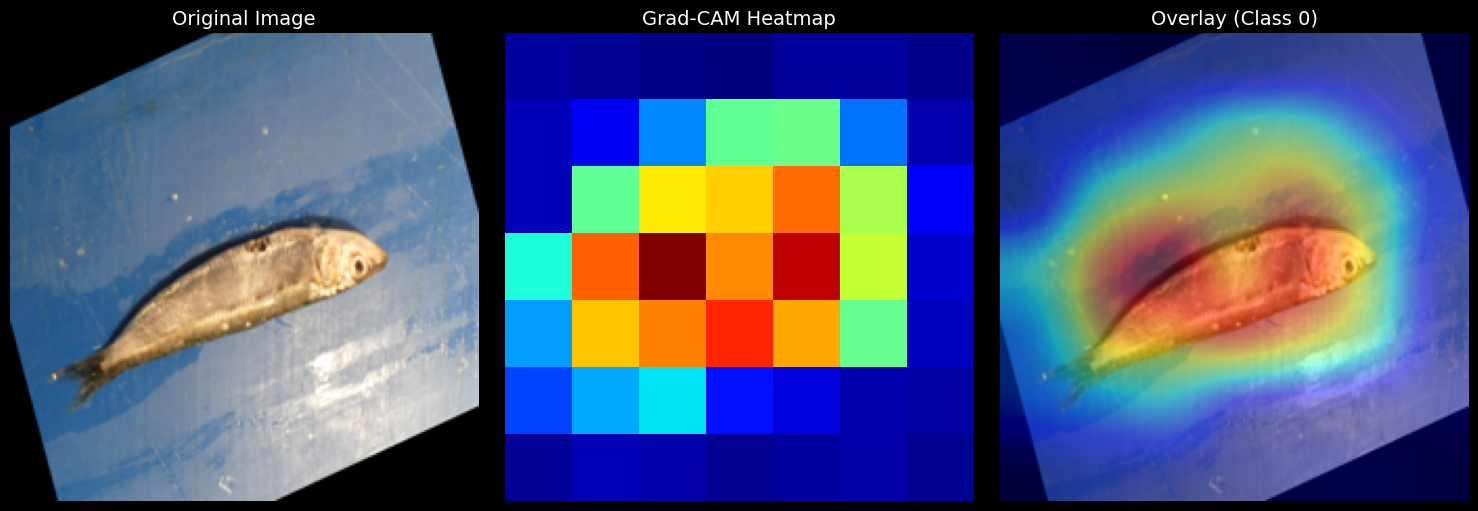

Saved to images/forced_class_1.png


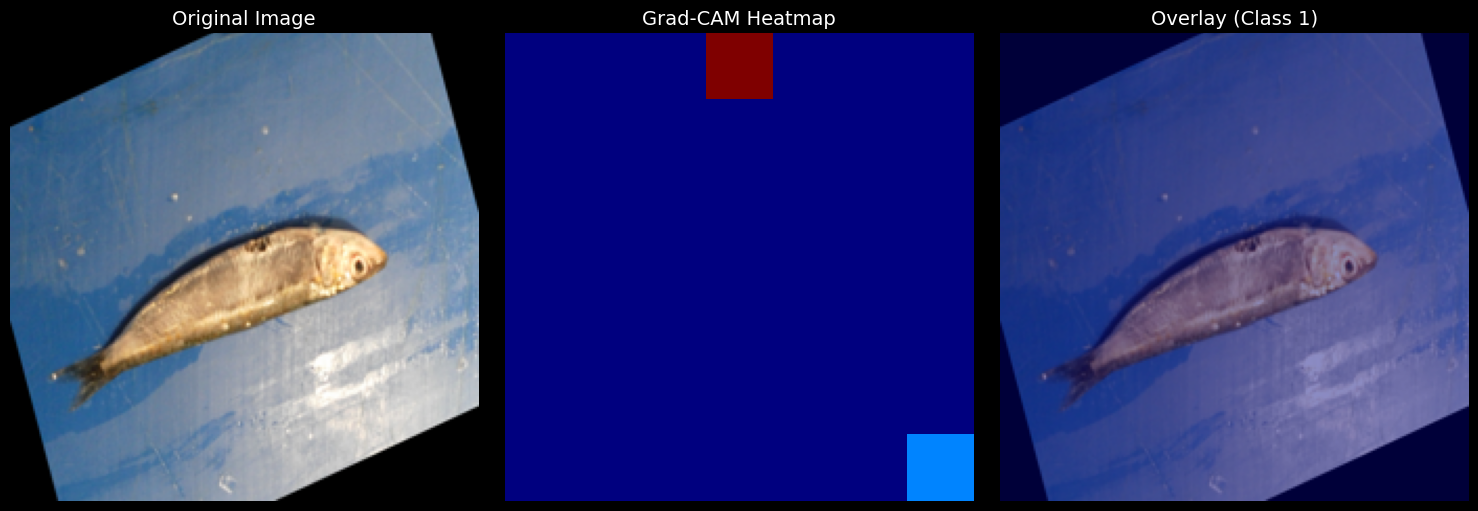

Saved to images/forced_class_2.png


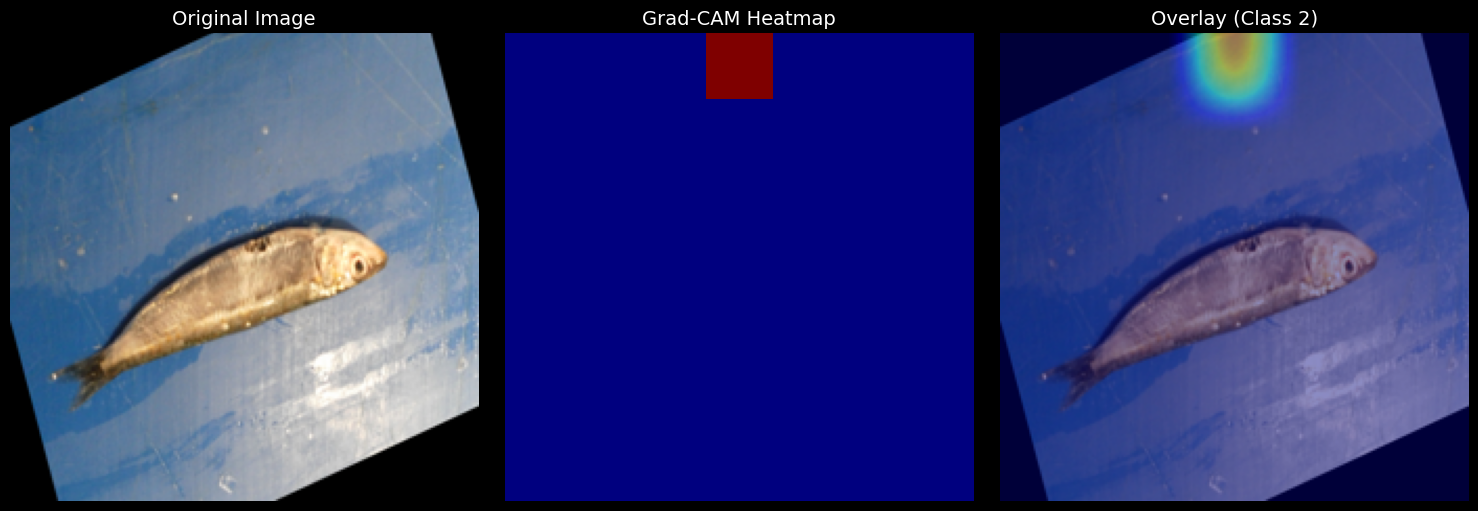

Saved to images/forced_class_3.png


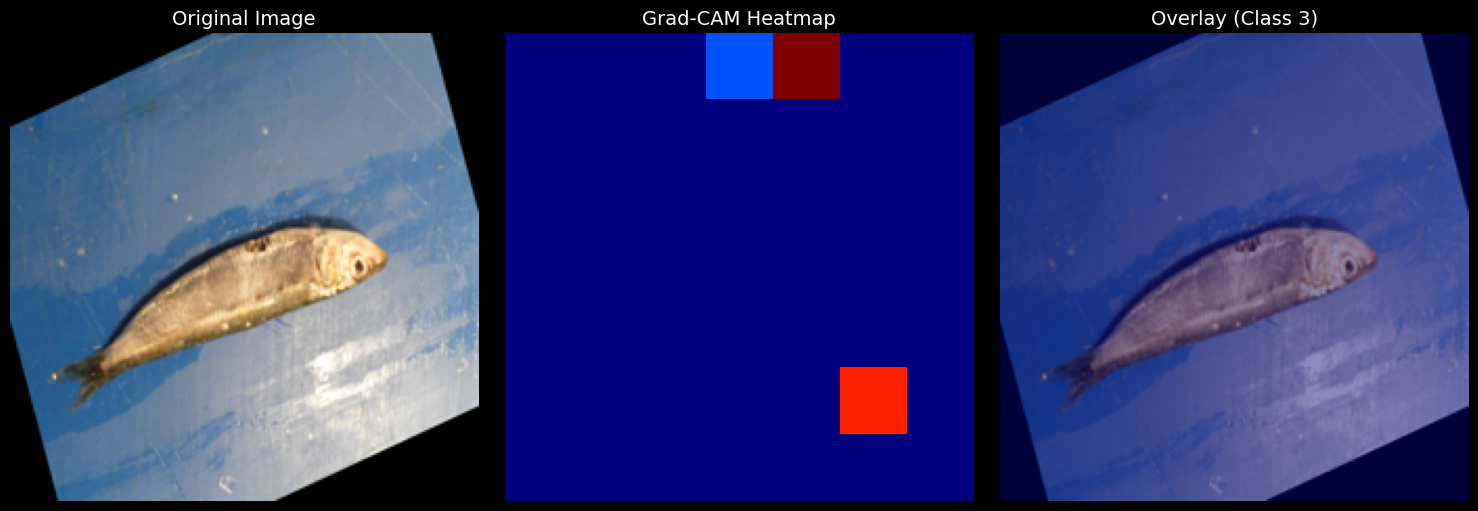

(<PIL.Image.Image image mode=RGB size=224x224>,
 array([[0.        , 0.        , 0.        , 0.00072535, 0.00352014,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.00307454, 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        ]], dtype=float32),
 <PIL.Image.Image image mode=RGB size=224x224>,
 3)

In [97]:

img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/Fish_Dataset/Fish_Dataset/Black Sea Sprat/Black Sea Sprat/00020.png"



img, heatmap, overlay, class_idx = visualize_gradcam(
    img_path=img_path,
    model=model,
    save_path='images/my_gradcam.png'
)

# Compare with various classes
visualize_gradcam(
    img_path=img_path,
    model=model,
    class_index=0,
    save_path='images/forced_class_0.png'
)
visualize_gradcam(
    img_path=img_path,
    model=model,
    class_index=1,
    save_path='images/forced_class_1.png'
)
visualize_gradcam(
    img_path=img_path,
    model=model,
    class_index=2,
    save_path='images/forced_class_2.png'
)
visualize_gradcam(
    img_path=img_path,
    model=model,
    class_index=3,
    save_path='images/forced_class_3.png'
)

# unrelated image in, predict it, then show heatmap

Saved to images/unrelated_gradcam_gilt_head_bream.png


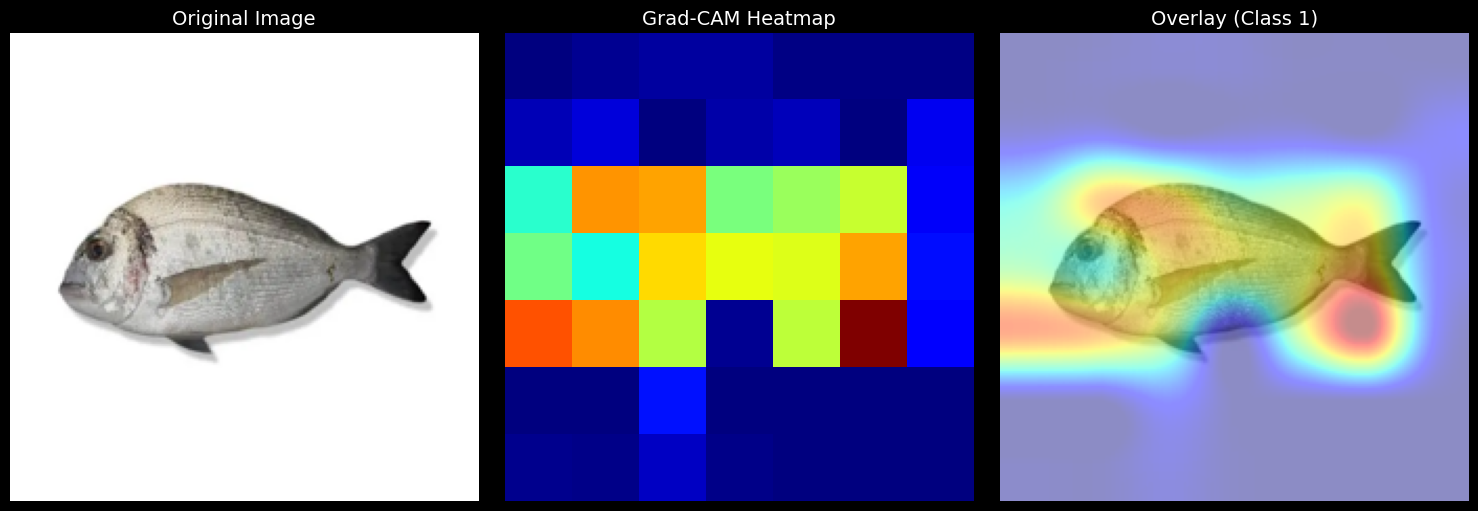

Predicted class index: 1


In [99]:
img_path = "/home/groggy/data/a-large-scale-fish-dataset/2/urelaterte_bilder/Gilt_head_bream.webp"

img, heatmap, overlay_img, class_idx = visualize_gradcam(
    img_path=img_path,
    model=model,
    save_path="images/unrelated_gradcam_gilt_head_bream.png"
)

print("Predicted class index:", class_idx)